# SupportFlow — dataset exploration

The AI triage in this project is scored against human labels rather than vibes.
This notebook establishes what those labels actually are: how many there are,
how balanced, how clean, and **what accuracy a trivial model already achieves** —
the number any LLM has to beat before it is worth anything.

Source: [multilingual customer support tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets)
(Tobias Bueck). Raw CSVs are gitignored; the paths below assume they sit in
`customer_support/` at the repo root.

In [1]:
import glob, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

# Validated categorical palette, fixed order (never cycled).
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
     "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10,
})

def bare(ax, axis="y"):
    """Recessive grid on one axis only."""
    ax.grid(axis=axis, alpha=0.9)
    ax.set_axisbelow(True)

DATA = "../customer_support"
print(sorted(os.path.basename(p) for p in glob.glob(f"{DATA}/*.csv")))

['aa_dataset-tickets-multi-lang-5-2-50-version.csv', 'dataset-tickets-german_normalized.csv', 'dataset-tickets-german_normalized_50_5_2.csv', 'dataset-tickets-multi-lang-4-20k.csv', 'dataset-tickets-multi-lang3-4k.csv']


## 1. What is actually in the corpus

Five files ship with the dataset and they do **not** share a schema. Counting
lines with `wc -l` gives ~136k, which is wrong — bodies contain newlines inside
quoted fields, so line count overstates records by roughly 2×. Parsing properly
is the only way to get a real number.

In [2]:
frames = {}
for path in sorted(glob.glob(f"{DATA}/*.csv")):
    frames[os.path.basename(path)] = pd.read_csv(path)

inventory = pd.DataFrame({
    "records": {k: len(v) for k, v in frames.items()},
    "columns": {k: v.shape[1] for k, v in frames.items()},
    "has_type": {k: "type" in v.columns for k, v in frames.items()},
    "has_queue": {k: "queue" in v.columns for k, v in frames.items()},
    "has_priority": {k: "priority" in v.columns for k, v in frames.items()},
})
inventory.loc["TOTAL"] = [inventory["records"].sum(), "", "", "", ""]
inventory

,records,columns,has_type,has_queue,has_priority
aa_dataset-tickets-multi-lang-5-2-50-version.csv,28587,16,True,True,True
dataset-tickets-german_normalized.csv,2125,5,False,True,True
dataset-tickets-german_normalized_50_5_2.csv,13178,5,False,True,True
dataset-tickets-multi-lang-4-20k.csv,20000,15,True,True,True
dataset-tickets-multi-lang3-4k.csv,4000,17,True,True,True
TOTAL,67890,,,,


Two of the five carry only `queue` and `priority`. The three fully-labelled
files are the usable corpus for triage evaluation, since `type` is one of the
three targets.

In [3]:
LABELS = ["type", "queue", "priority"]
labelled = pd.concat(
    [df for df in frames.values() if all(c in df.columns for c in LABELS)],
    ignore_index=True,
)[["subject", "body", "answer", "type", "queue", "priority", "language"]]

print(f"fully-labelled records : {len(labelled):,}")
print(f"of all records         : {len(labelled) / inventory.loc['TOTAL', 'records']:.0%}")
labelled.head(3)

fully-labelled records : 52,587
of all records         : 77%


,subject,body,answer,type,queue,priority,language
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en


## 2. Language — the demo and the evaluation are English-only

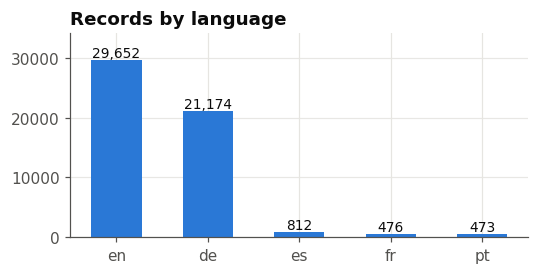

English records: 29,652


In [4]:
lang = labelled["language"].value_counts()
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.bar(lang.index, lang.values, color=C[0], width=0.55)
for x, v in zip(lang.index, lang.values):
    ax.text(x, v, f"{v:,}", ha="center", va="bottom", color=INK, fontsize=9)
ax.set_title("Records by language", loc="left", fontweight="semibold")
ax.set_ylim(0, lang.max() * 1.15); bare(ax)
plt.tight_layout(); plt.show()

en = labelled[labelled["language"] == "en"].copy()
print(f"English records: {len(en):,}")

## 3. Label distributions

Three targets of very different difficulty: `priority` is 3-way, `type` 4-way,
`queue` 10-way. Class balance matters more than class count — a target where one
class holds most of the mass is easy to score well on and hard to be useful at.

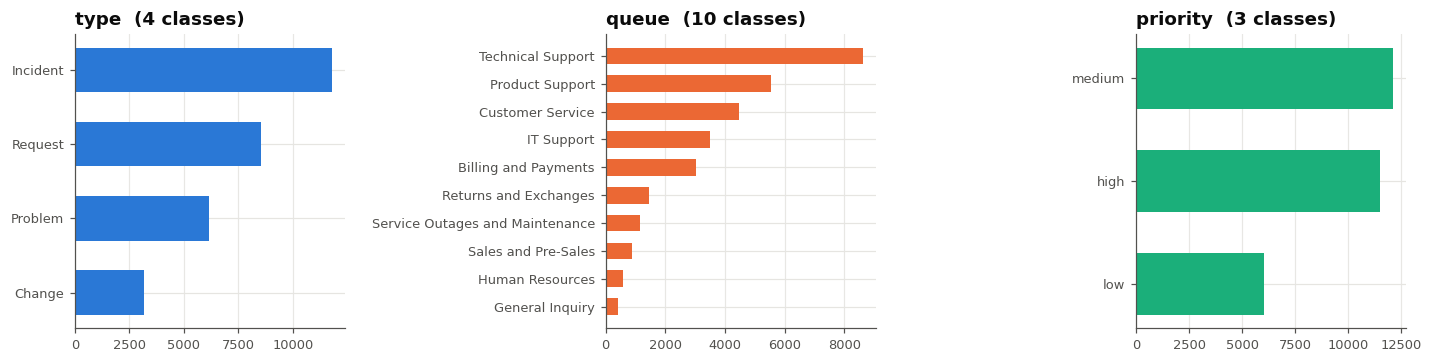

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, colour in zip(axes, LABELS, [C[0], C[1], C[2]]):
    vc = en[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color=colour, height=0.6)
    ax.set_title(f"{col}  ({en[col].nunique()} classes)", loc="left", fontweight="semibold")
    ax.tick_params(labelsize=8.5)
    bare(ax, axis="x")
plt.tight_layout(); plt.show()

## 4. The number that matters: what a trivial model already gets

Always-predict-the-majority-class is the floor. A model that cannot beat it has
learned nothing, and on an imbalanced target that floor can be high enough to
make a mediocre model look respectable.

This is the baseline the LLM triage is scored against in phase C.

In [6]:
floor = pd.DataFrame({
    "classes": {c: en[c].nunique() for c in LABELS},
    "majority class": {c: en[c].value_counts().idxmax() for c in LABELS},
    "majority-class accuracy": {c: en[c].value_counts(normalize=True).max() for c in LABELS},
    "uniform-guess accuracy": {c: 1 / en[c].nunique() for c in LABELS},
})
floor["majority-class accuracy"] = floor["majority-class accuracy"].map("{:.1%}".format)
floor["uniform-guess accuracy"] = floor["uniform-guess accuracy"].map("{:.1%}".format)
floor

,classes,majority class,majority-class accuracy,uniform-guess accuracy
type,4,Incident,39.8%,25.0%
queue,10,Technical Support,29.1%,10.0%
priority,3,medium,40.9%,33.3%


`priority` is the cautionary one: the majority class alone scores in the 40s,
so headline accuracy is a poor way to judge it. Per-class recall — especially on
`high`, the class that actually costs money when missed — is the metric with
teeth.

## 5. Text length — how much context a model gets per ticket

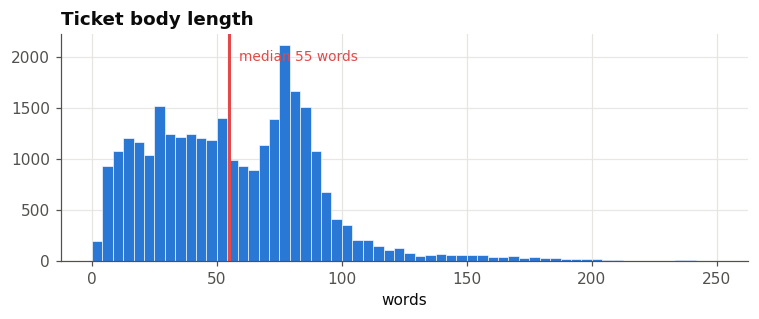

,mean,50%,min,max
subject_words,5.016761,5.0,0.0,37.0
body_words,57.681978,55.0,0.0,368.0


In [7]:
en["body_words"] = en["body"].fillna("").str.split().str.len()
en["subject_words"] = en["subject"].fillna("").str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(en["body_words"], bins=60, range=(0, 250), color=C[0], edgecolor="white", linewidth=0.4)
med = en["body_words"].median()
ax.axvline(med, color=C[7], linewidth=2)
ax.text(med + 4, ax.get_ylim()[1] * 0.88, f"median {med:.0f} words", color=C[7], fontsize=9)
ax.set_title("Ticket body length", loc="left", fontweight="semibold")
ax.set_xlabel("words"); bare(ax)
plt.tight_layout(); plt.show()

en[["subject_words", "body_words"]].describe().T[["mean", "50%", "min", "max"]]

Short. A median body of well under 100 words means a whole ticket fits in a
prompt comfortably, so token cost per triage call is low and truncation is not a
design concern.

## 6. Label quality — before trusting any of it as ground truth

In [8]:
quality = {
    "missing subject": en["subject"].isna().sum(),
    "missing body": en["body"].isna().sum(),
    "missing answer": en["answer"].isna().sum(),
    "blank body after strip": (en["body"].fillna("").str.strip() == "").sum(),
    "exact duplicate bodies": en["body"].duplicated().sum(),
    "duplicate subjects": en["subject"].duplicated().sum(),
}
pd.Series(quality).to_frame("count")

,count
missing subject,3810
missing body,2
missing answer,6
blank body after strip,2
exact duplicate bodies,4596
duplicate subjects,9388


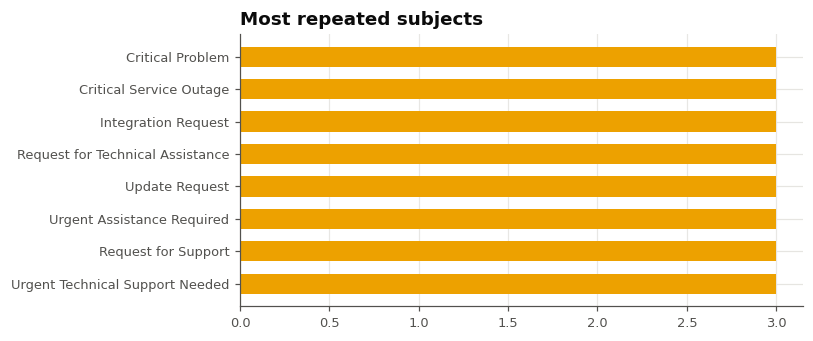

In [9]:
top_subjects = en["subject"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(top_subjects.index[::-1], top_subjects.values[::-1], color=C[3], height=0.62)
ax.set_title("Most repeated subjects", loc="left", fontweight="semibold")
ax.tick_params(labelsize=8.5); bare(ax, axis="x")
plt.tight_layout(); plt.show()

Subjects repeat heavily — generic openers like "Customer Support Inquiry"
recur hundreds of times. That is a leakage trap: a train/test split that puts
identical subjects on both sides flatters the model. Phase C splits so that a
duplicated subject cannot straddle the boundary.

## 7. Is there signal? Priority against type

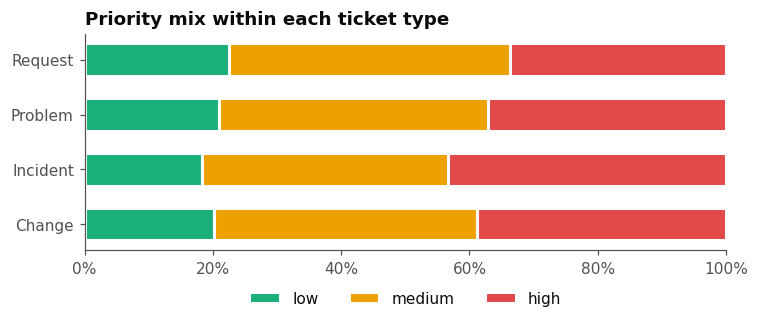

priority,low,medium,high
type,,,
Change,20.1,41.0,38.9
Incident,18.4,38.3,43.4
Problem,20.9,42.0,37.1
Request,22.5,43.7,33.8


In [10]:
ct = pd.crosstab(en["type"], en["priority"], normalize="index")[["low", "medium", "high"]]

fig, ax = plt.subplots(figsize=(7, 3.2))
left = np.zeros(len(ct))
for colour, col in zip([C[2], C[3], C[7]], ct.columns):
    ax.barh(ct.index, ct[col], left=left, color=colour, height=0.6, label=col,
            edgecolor="white", linewidth=2)   # 2px surface gap between segments
    left += ct[col].values
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Priority mix within each ticket type", loc="left", fontweight="semibold")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.32))
ax.grid(False)
plt.tight_layout(); plt.show()
(ct * 100).round(1)

The mix shifts by type — `Incident` skews high, `Change` skews low — so `type`
carries real information about `priority`. Weak but present, which is the honest
description: enough for a model to learn from, not enough to make the task easy.

---

## What this sets up for phase C

- **Beat these floors, not zero.** Majority-class accuracy is the bar; per-class
  recall on `high` priority is the metric that matters operationally.
- **Split on deduplicated subjects**, or repeated generic subjects leak across
  train and test.
- **`queue` is the hard target** at 10 classes with a long tail; `priority` is the
  useful one, and the one the product actually acts on.
- Tickets are short, so a full ticket fits in a prompt and per-call cost stays low.